# Predictive Modeling Study on New York Housing Rental Price

## I. Introduction
* Project motivation:

  NYC rent varies greatly across boroughs and changes over time. This project studies **whether historical rent trends can predict future rental prices**.

* Data overview:

  We use [Zillow Observed Rent Index (ZORI)](https://www.zillow.com/research/data/) monthly data at the ZIP-code level. Each row represents one ZIP code in one month.


* Exploratory Data Analysis:

  Before building prediction models, we use EDA to understand **rent patterns across boroughs, ZIP codes, and time**. The visualizations help identify spatial rent differences, post-2020 rent changes, and the special position of Long Island City within Queens. These patterns motivate our later hypothesis that historical rent values and location-related features can help predict future rent.



* Predictive task:

  The main task is to **predict next month’s rent index** using current rent, lagged rent values, rent growth, time features, borough, and a Long Island City indicator.

* Models used:

  We compare Linear Regression, Ridge Regression, KNN Regression, Random Forest Regression, Logistic Regression classification, and time-series forecasting models including ARIMA and Exponential Smoothing.

* Summary findings:

  * **Linear Regression performs best for rent prediction**.
  
  * **Logistic Regression performs best for high-rent classification**.
  
  * **Exponential Smoothing performs best in the forecasting extension**.




## II. Data Description and Data Preparation

We use [Zillow Observed Rent Index data](https://www.zillow.com/research/data/) (ZORI) at the ZIP-code-month level. After filtering to New York City ZIP codes, we transform the data from wide to long format and create lag features from past rent values. The predictive task is to estimate next month’s rent index using current rent, previous rent levels, rent growth, borough, and time features.

***Note**: Here's a link to [the methodology of how ZORI is calculated](https://www.zillow.com/research/methodology-zori-repeat-rent-27092/).

In one sentense, ZORI is a repeat-rent index that measures the typical, observed market-rate rent across a given region

### 1. Access Dataset and Build DataFrame



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the data
zori_raw = pd.read_csv("/content/zori_zip.csv")

print(zori_raw.shape)
zori_raw.head()


(8188, 144)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2015-01-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,1396.420611,...,1752.349869,1761.399334,1768.181320,1762.748802,1752.914282,1739.839933,1735.345787,1716.202697,1704.095737,1683.654847
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2305.088360,2379.926927,2310.000000
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,1238.667257,...,1825.135558,1823.161847,1814.078021,1805.419803,1804.616865,1793.828474,1804.151902,1793.823253,1797.458821,1779.454743
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2700.000000
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,1093.863007,...,1576.421608,1573.457268,1579.511547,1579.319611,1574.482724,1564.271077,1559.644039,1559.997423,1554.930010,1544.184291


In [ ]:
# check columns
zori_raw.columns.tolist()[:15]

['RegionID',
 'SizeRank',
 'RegionName',
 'RegionType',
 'StateName',
 'State',
 'City',
 'Metro',
 'CountyName',
 '2015-01-31',
 '2015-02-28',
 '2015-03-31',
 '2015-04-30',
 '2015-05-31',
 '2015-06-30']

### 2. Data Cleaning


In [ ]:
# Filter to NYC ZIP codes
nyc_counties = [
    "New York County",   # Manhattan
    "Kings County",      # Brooklyn
    "Queens County",     # Queens
    "Bronx County",      # Bronx
    "Richmond County"    # Staten Island
]

zori_nyc = zori_raw[
    (zori_raw["StateName"] == "NY") &
    (zori_raw["CountyName"].isin(nyc_counties))
].copy()

print(zori_nyc.shape)
zori_nyc.head()

(152, 144)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2015-01-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2700.000000
6,62093,7,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,3044.561878,3110.006786,3089.504783,3071.414298,3031.055703,3014.708892,2973.686373,3010.333460,3059.504855,3110.629630
8,62019,9,11208,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,NaN,...,2845.342594,2909.551010,3016.331449,3072.160061,3155.939273,3205.441432,3065.921897,2976.415274,3017.804947,3076.214286
15,62046,16,11236,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,NaN,...,NaN,NaN,2857.114308,2958.952092,3128.457579,3180.443234,3064.320348,3156.161825,3143.126917,3162.500000
16,61807,17,10467,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Bronx County,NaN,...,2416.595951,2534.798815,2606.677096,2530.246942,2581.748354,2558.887553,2569.694683,2487.993981,2545.825631,2629.875000


In [ ]:
# Add borough
county_to_borough = {
    "New York County": "Manhattan",
    "Kings County": "Brooklyn",
    "Queens County": "Queens",
    "Bronx County": "Bronx",
    "Richmond County": "Staten Island"
}

zori_nyc["borough"] = zori_nyc["CountyName"].map(county_to_borough)

### 3. Feature engineering

**Convert from wide to long format**

In [ ]:
# turns many monthly columns into one date column and one zori_rent column
id_cols = [
    "RegionID",
    "SizeRank",
    "RegionName",
    "RegionType",
    "StateName",
    "State",
    "City",
    "Metro",
    "CountyName",
    "borough"
]

date_cols = [col for col in zori_nyc.columns if col not in id_cols]

zori_long = zori_nyc.melt(
    id_vars=id_cols,
    value_vars=date_cols,
    var_name="date",
    value_name="zori_rent"
)

zori_long["date"] = pd.to_datetime(zori_long["date"], errors="coerce")
zori_long = zori_long.dropna(subset=["date", "zori_rent"])

zori_long = zori_long.rename(columns={
    "RegionName": "zip_code",
    "CountyName": "county"
})

zori_long["zip_code"] = zori_long["zip_code"].astype(str)

print(zori_long.shape)
zori_long.head()

(12541, 12)


,RegionID,SizeRank,zip_code,RegionType,StateName,State,City,Metro,county,borough,date,zori_rent
6,62037,19,11226,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,Brooklyn,2015-01-31,1876.767896
7,62018,20,11207,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,Brooklyn,2015-01-31,1771.672139
8,61639,29,10025,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,2015-01-31,3044.118997
14,62017,47,11206,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,Brooklyn,2015-01-31,2435.755684
15,62032,48,11221,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,Brooklyn,2015-01-31,1964.510744


**Create lag feature**

These are the most important predictive features.

Rent is highly **time-dependent**. The best predictor of next month’s rent is often this month’s rent and recent rent trend.

So, instead of predicting with only:

  * borough, month, year

we  predict with:

  * current rent

  * last month’s rent

  * rent 3 months ago

  * rent 12 months ago

  * recent growth

  * seasonality

  * borough




In [ ]:
# create time features
zori_long["year"] = zori_long["date"].dt.year
zori_long["month"] = zori_long["date"].dt.month
zori_long["quarter"] = zori_long["date"].dt.quarter
zori_long = zori_long.sort_values(["zip_code", "date"])

# create lag features
zori_long["rent_lag_1"] = zori_long.groupby("zip_code")["zori_rent"].shift(1)
zori_long["rent_lag_2"] = zori_long.groupby("zip_code")["zori_rent"].shift(2)
zori_long["rent_lag_3"] = zori_long.groupby("zip_code")["zori_rent"].shift(3)
zori_long["rent_lag_12"] = zori_long.groupby("zip_code")["zori_rent"].shift(12)

# create rent growth features
zori_long["rent_growth_1m"] = (
    zori_long["zori_rent"] - zori_long["rent_lag_1"]
) / zori_long["rent_lag_1"]
zori_long["rent_growth_12m"] = (
    zori_long["zori_rent"] - zori_long["rent_lag_12"]
) / zori_long["rent_lag_12"]

# create target variable
zori_long["target_next_month_rent"] = (
    zori_long.groupby("zip_code")["zori_rent"].shift(-1)
)

# create is_lic variable
lic_zips = ["11101", "11109"]
zori_long["is_lic"] = zori_long["zip_code"].astype(str).isin(lic_zips).astype(int)
zori_long["zip_code"] = zori_long["zip_code"].astype(str)


model_df = zori_long.dropna(subset=[
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "target_next_month_rent",
    "is_lic"
]).copy()

print(model_df.shape)
model_df.head()

(10849, 23)


,RegionID,SizeRank,zip_code,RegionType,StateName,State,City,Metro,county,borough,...,month,quarter,rent_lag_1,rent_lag_2,rent_lag_3,rent_lag_12,rent_growth_1m,rent_growth_12m,target_next_month_rent,is_lic
1947,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,1,1,4076.478274,4084.053297,4136.821172,3958.238156,-0.006741,0.022930,4041.609677,0
2099,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,2,1,4048.999810,4076.478274,4084.053297,3989.656803,-0.001825,0.013022,4056.968346,0
2251,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,3,1,4041.609677,4048.999810,4076.478274,3996.446526,0.003800,0.015144,4087.752041,0
2403,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,4,2,4056.968346,4041.609677,4048.999810,4073.226094,0.007588,0.003566,4139.052840,0
2555,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,5,2,4087.752041,4056.968346,4041.609677,4143.042151,0.012550,-0.000963,4150.624433,0


**Final Model DataFrame**

In [ ]:
final_cols = [
    "zip_code",
    "borough",
    "city",
    "county",
    "date",
    "year",
    "month",
    "quarter",
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "target_next_month_rent",
    "is_lic" # Add is_lic to final_cols
]

# Ensure 'City' is renamed to 'city' in model_df
# model_df is assumed to already contain 'is_lic' from its creation based on zori_long
model_df = model_df.rename(columns={"City": "city"})

# Now model_df should have 'city' (lowercase) and 'is_lic'
model_df_final = model_df[final_cols].copy()

print(model_df_final.shape)
model_df_final.head()

(10849, 17)


,zip_code,borough,city,county,date,year,month,quarter,zori_rent,rent_lag_1,rent_lag_2,rent_lag_3,rent_lag_12,rent_growth_1m,rent_growth_12m,target_next_month_rent,is_lic
1947,10001,Manhattan,New York,New York County,2016-01-31,2016,1,1,4048.999810,4076.478274,4084.053297,4136.821172,3958.238156,-0.006741,0.022930,4041.609677,0
2099,10001,Manhattan,New York,New York County,2016-02-29,2016,2,1,4041.609677,4048.999810,4076.478274,4084.053297,3989.656803,-0.001825,0.013022,4056.968346,0
2251,10001,Manhattan,New York,New York County,2016-03-31,2016,3,1,4056.968346,4041.609677,4048.999810,4076.478274,3996.446526,0.003800,0.015144,4087.752041,0
2403,10001,Manhattan,New York,New York County,2016-04-30,2016,4,2,4087.752041,4056.968346,4041.609677,4048.999810,4073.226094,0.007588,0.003566,4139.052840,0
2555,10001,Manhattan,New York,New York County,2016-05-31,2016,5,2,4139.052840,4087.752041,4056.968346,4041.609677,4143.042151,0.012550,-0.000963,4150.624433,0


## III. Exploratory Data Analysis

### 1. Main Features


*   monthly rent index
*   borough
*   ZIP code
*   LIC vs other Queens
*   year
*   month
*   rent growth

In [ ]:
# Choose features for EDA
eda_df = zori_long[
    [
        "zip_code",
        "borough",
        "date",
        "year",
        "month",
        "zori_rent",
        "rent_growth_1m",
        "rent_growth_12m",
        "is_lic"
    ]
].copy()

# Create LIC vs other Queens group
lic_vs_queens = zori_long[
    (zori_long["borough"] == "Queens") | (zori_long["is_lic"] == 1)
].copy()

lic_vs_queens["area_group"] = np.where(
    lic_vs_queens["is_lic"] == 1,
    "Long Island City",
    "Other Queens"
)

print(eda_df.shape)
eda_df.head()

(12541, 9)


,zip_code,borough,date,year,month,zori_rent,rent_growth_1m,rent_growth_12m,is_lic
123,10001,Manhattan,2015-01-31,2015,1,3958.238156,NaN,NaN,0
275,10001,Manhattan,2015-02-28,2015,2,3989.656803,0.007938,NaN,0
427,10001,Manhattan,2015-03-31,2015,3,3996.446526,0.001702,NaN,0
579,10001,Manhattan,2015-04-30,2015,4,4073.226094,0.019212,NaN,0
731,10001,Manhattan,2015-05-31,2015,5,4143.042151,0.017140,NaN,0


### 2. Visualization

***Note on ZORI rent values:**  
The rental price variable in this project is based on Zillow Observed Rent Index (ZORI). ZORI represents a typical observed market rent at the ZIP-code level, not the simple average rent of all currently listed apartments. Because it reflects broader market-level trends across housing units and property types, its values may look lower than the rents commonly seen on rental platforms, especially for popular or luxury one-bedroom apartments in Manhattan. Therefore, we interpret ZORI mainly as a comparable rent index for analyzing borough-level, ZIP-code-level, and time-series patterns.

**Rent trend over time by borough**

The rent trend shows that Manhattan consistently has the highest rent level, followed by Brooklyn and Queens. All boroughs experienced a clear rent drop around 2020–2021, likely reflecting the pandemic-period rental market shock, followed by a strong recovery and continued growth after 2021.

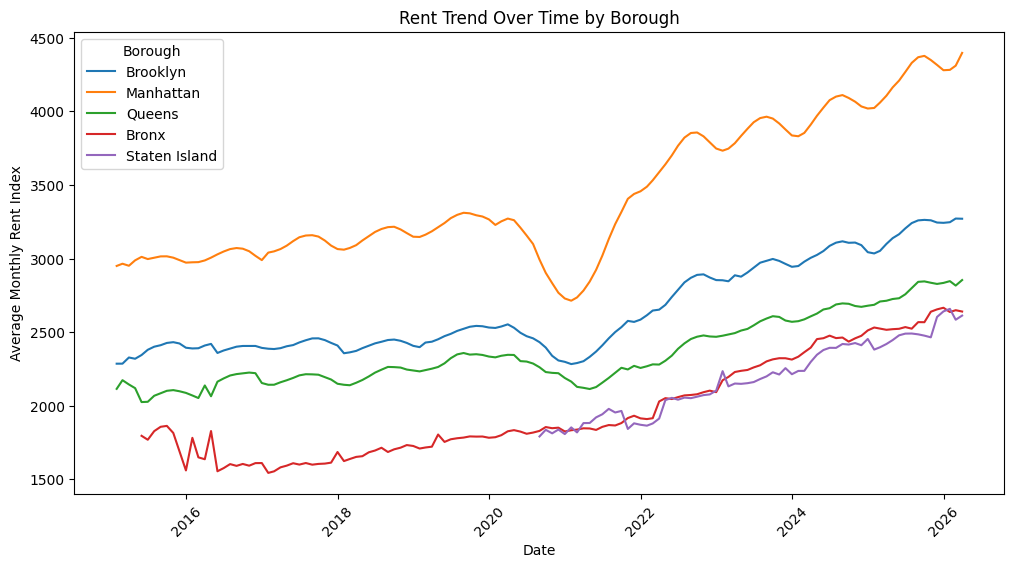

In [ ]:
# Average monthly rent trend by borough
borough_rent_trend = (
    eda_df
    .groupby(["date", "borough"])
    .agg(avg_rent=("zori_rent", "mean"))
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=borough_rent_trend,
    x="date",
    y="avg_rent",
    hue="borough"
)

plt.title("Rent Trend Over Time by Borough")
plt.xlabel("Date")
plt.ylabel("Average Monthly Rent Index")
plt.xticks(rotation=45)
plt.legend(title="Borough")
plt.show()

**Average rent by borough (2026)**

In 2026, Manhattan has the highest average ZORI rent among the five boroughs, at about \$4,331. Brooklyn is the second highest, around \$3,263, followed by Queens at about \$2,840. The Bronx and Staten Island have the lowest average rents, both around \$2,600. Overall, the result shows a clear rent gap between Manhattan and the other boroughs, while Brooklyn and Queens form a middle-rent group and the Bronx/Staten Island remain relatively more affordable.

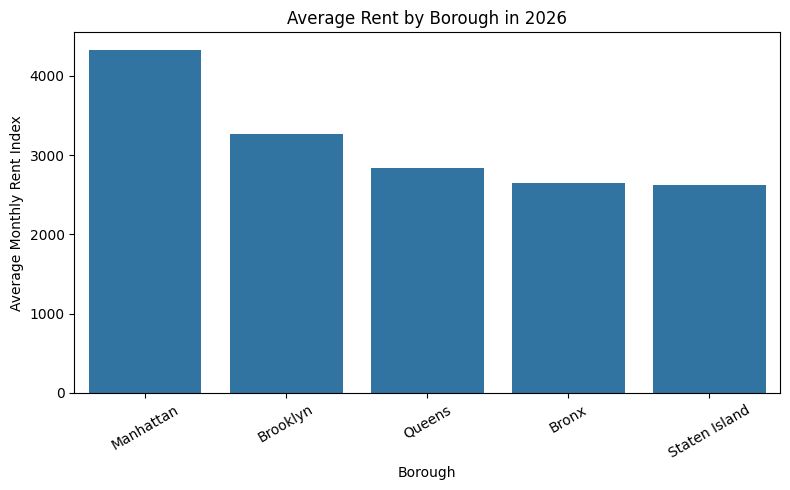

,borough,avg_rent
2,Manhattan,4330.982463
1,Brooklyn,3263.439071
3,Queens,2840.053053
0,Bronx,2641.883506
4,Staten Island,2620.015243


In [ ]:
# Average rent by borough in 2026
rent_2026 = eda_df[eda_df["year"] == 2026].copy()

rent_by_borough_2026 = (
    rent_2026
    .groupby("borough")
    .agg(avg_rent=("zori_rent", "mean"))
    .reset_index()
    .sort_values("avg_rent", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=rent_by_borough_2026,
    x="borough",
    y="avg_rent"
)

plt.title("Average Rent by Borough in 2026")
plt.xlabel("Borough")
plt.ylabel("Average Monthly Rent Index")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

rent_by_borough_2026

**Rent distribution (2026)**

The 2026 rent distribution shows that Manhattan has both the highest rent level and the widest spread. Most Manhattan ZIP-code observations are above \$4,000, with some high-rent areas reaching over \$7,000. Queens, the Bronx, and Staten Island are more concentrated around \$2,500–\$3,000, suggesting relatively lower and more stable rent levels. Brooklyn falls between these groups: its rent distribution overlaps with Queens in the lower range, but also extends toward higher values, showing greater variation across neighborhoods. Overall, the distribution confirms that Manhattan is the most expensive and least homogeneous borough in terms of rent.


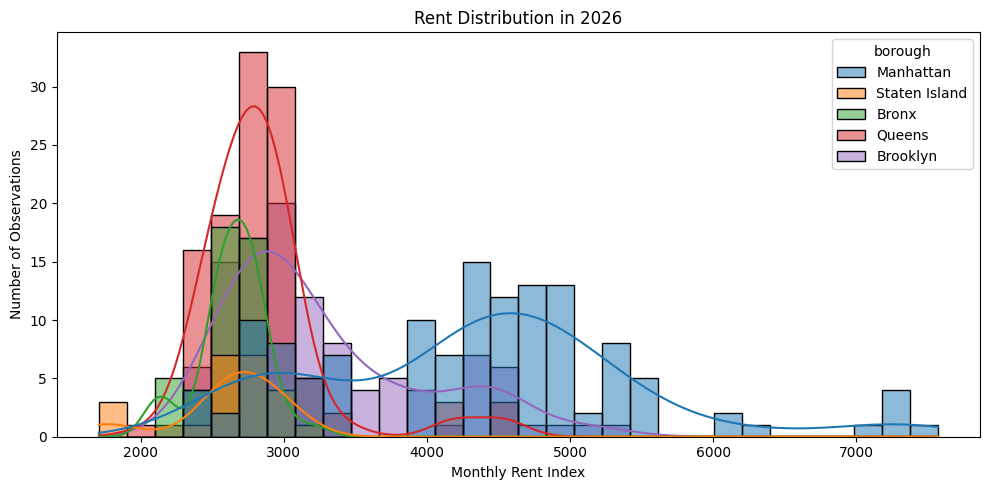

In [ ]:
# Rent distribution in 2026
rent_2026 = eda_df[eda_df["year"] == 2026].copy()

plt.figure(figsize=(10, 5))
sns.histplot(
    data=rent_2026,
    x="zori_rent",
    hue="borough",
    bins=30,
    kde=True
)

plt.title("Rent Distribution in 2026")
plt.xlabel("Monthly Rent Index")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

**Monthly rent growth trend**

Rent growth dropped sharply around 2020, especially in the 12-month growth rate, reflecting the COVID-era rental market shock. After 2021, rent growth rebounded quickly and peaked around 2022. Since then, growth has slowed but remained mostly positive through 2026.


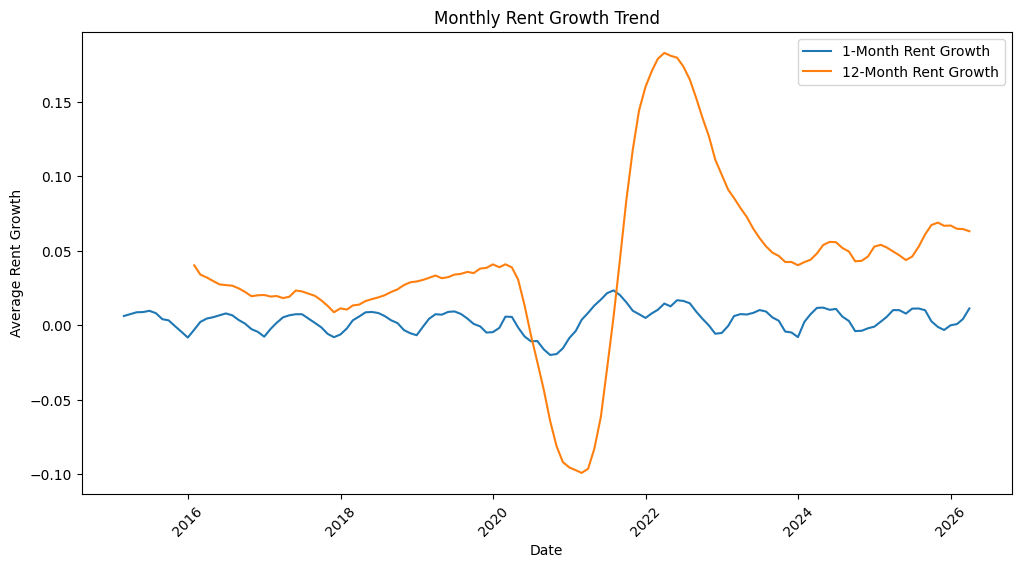

,date,avg_rent_growth_1m,avg_rent_growth_12m
132,2026-01-31,0.000869,0.064785
133,2026-02-28,0.004220,0.064610
134,2026-03-31,0.011344,0.063161


In [ ]:
# Monthly rent growth trend
monthly_growth_trend = (
    eda_df
    .groupby("date")
    .agg(
        avg_rent_growth_1m=("rent_growth_1m", "mean"),
        avg_rent_growth_12m=("rent_growth_12m", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth_trend["date"],
    monthly_growth_trend["avg_rent_growth_1m"],
    label="1-Month Rent Growth"
)

plt.plot(
    monthly_growth_trend["date"],
    monthly_growth_trend["avg_rent_growth_12m"],
    label="12-Month Rent Growth"
)

plt.title("Monthly Rent Growth Trend")
plt.xlabel("Date")
plt.ylabel("Average Rent Growth")
plt.legend()
plt.xticks(rotation=45)
plt.show()

monthly_growth_trend[monthly_growth_trend["date"].dt.year == 2026].head()

**LIC vs Other Queens rent trend**

Long Island City has consistently higher rent than the rest of Queens. After a short decline around 2020–2021, LIC rent rebounded strongly and reached about \$4,300–\$4,400 by early 2026. Other Queens also increased, but much more gradually, staying around \$2,700.


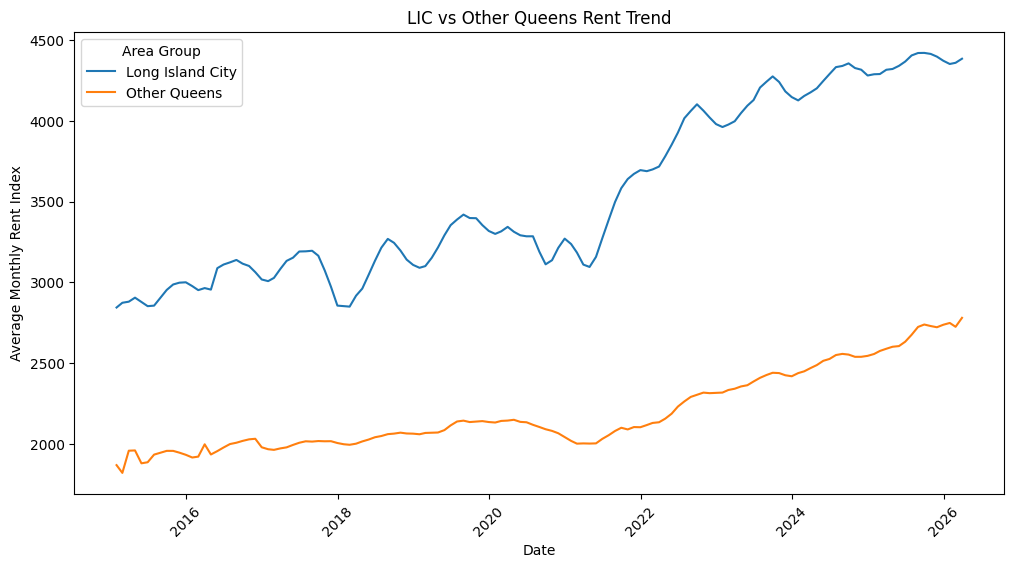

,date,area_group,avg_rent
264,2026-01-31,Long Island City,4350.075563
265,2026-01-31,Other Queens,2749.774112
266,2026-02-28,Long Island City,4357.416104
267,2026-02-28,Other Queens,2725.995268
268,2026-03-31,Long Island City,4382.671403


In [ ]:
# LIC vs other Queens rent trend
lic_queens_rent_trend = (
    lic_vs_queens
    .groupby(["date", "area_group"])
    .agg(avg_rent=("zori_rent", "mean"))
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=lic_queens_rent_trend,
    x="date",
    y="avg_rent",
    hue="area_group"
)

plt.title("LIC vs Other Queens Rent Trend")
plt.xlabel("Date")
plt.ylabel("Average Monthly Rent Index")
plt.legend(title="Area Group")
plt.xticks(rotation=45)
plt.show()

lic_queens_rent_trend[lic_queens_rent_trend["date"].dt.year == 2026].head()

**Rent distribution heatmap by borough (2026)**

This heatmap shows how 2026 rent observations are distributed across rent ranges in each borough. Manhattan has more observations in the higher rent ranges, while Queens, the Bronx, and Staten Island are mostly concentrated in lower rent ranges. This confirms that rent differences are not only about average rent, but also about how rent levels are distributed across areas.

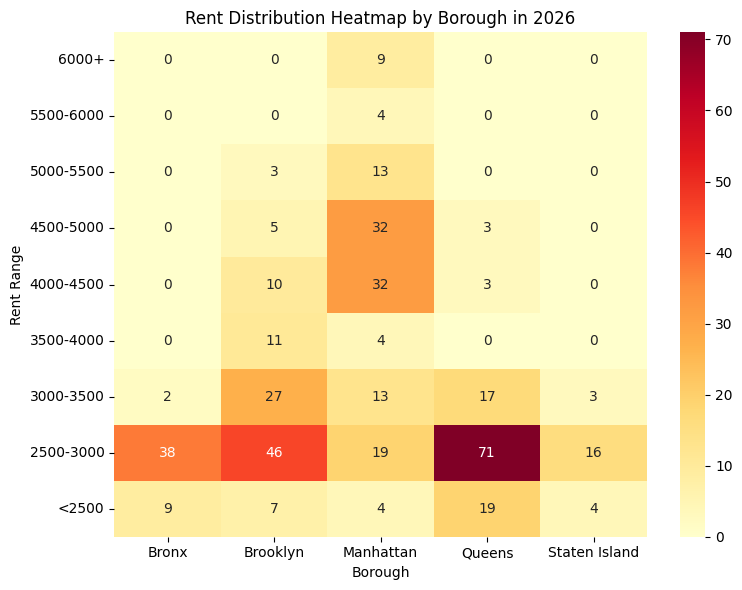

,zip_code,borough,avg_rent,zip_label
43,10282,Manhattan,7341.229587,10282 (Manhattan)
6,10007,Manhattan,7218.271090,10007 (Manhattan)
11,10013,Manhattan,6171.736032,10013 (Manhattan)
0,10001,Manhattan,5496.359172,10001 (Manhattan)
41,10162,Manhattan,5495.000000,10162 (Manhattan)
12,10014,Manhattan,5465.952742,10014 (Manhattan)
38,10069,Manhattan,5292.767359,10069 (Manhattan)
9,10011,Manhattan,5272.248918,10011 (Manhattan)
114,11249,Brooklyn,5121.253629,11249 (Brooklyn)
8,10010,Manhattan,5042.705149,10010 (Manhattan)


In [ ]:
# Rent range heatmap by borough in 2026
rent_2026 = eda_df[eda_df["year"] == 2026].copy()

rent_bins = [0, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, np.inf]
rent_labels = [
    "<2500",
    "2500-3000",
    "3000-3500",
    "3500-4000",
    "4000-4500",
    "4500-5000",
    "5000-5500",
    "5500-6000",
    "6000+"
]

rent_2026["rent_range"] = pd.cut(
    rent_2026["zori_rent"],
    bins=rent_bins,
    labels=rent_labels,
    include_lowest=True
)

rent_heatmap = pd.crosstab(
    rent_2026["rent_range"],
    rent_2026["borough"]
)

# Put higher rent ranges at the top
rent_heatmap = rent_heatmap.reindex(rent_labels[::-1])

plt.figure(figsize=(8, 6))
sns.heatmap(
    rent_heatmap,
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title("Rent Distribution Heatmap by Borough in 2026")
plt.xlabel("Borough")
plt.ylabel("Rent Range")
plt.tight_layout()
plt.show()

rent_heatmap
top_zip_heatmap_2026

### 3. Social Media Complaint Analysis

To add social context to the Zillow rent index data, we collect Reddit posts from NYC-related subreddits using rent-related search terms. We classify posts as complaints if they contain keywords such as “expensive,” “unaffordable,” “priced out,” or “too high.” We then aggregate the results by month to compare online complaint intensity with rental market trends.

* Data source: Reddit posts
* Unit: post
* Time level: month or year
* Purpose: measure rent complaint frequency and intensity

In [ ]:
!pip install praw textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 7.1 MB/s eta 0:00:00


In [ ]:
import praw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob

# borrowing reddit from lenny
reddit = praw.Reddit(
    client_id="Q_QXuXryk45yUw",
    client_secret="V39giI7Gkf8rIB6lCaE_NcuagHs",
    user_agent="lenny",
)

print("Read only:", reddit.read_only)

Read only: True


In [ ]:
# Choose NYC-related subreddits
# These subreddits often contain discussions about NYC apartments, rent, landlords, and housing
subreddits = ["AskNYC", "NYCapartments", "nyc", "newyorkcity"]

# Search terms related to rent and housing problems
# Each query will be searched inside each subreddit
search_queries = [
    "rent",
    "apartment rent",
    "rent increase",
    "landlord",
    "broker fee",
    "lease",
    "priced out"
]

# Empty list to store all collected Reddit posts
posts = []

# Loop through each subreddit and each search term
for sub in subreddits:
    subreddit = reddit.subreddit(sub)

    for query in search_queries:
        print(f"Searching r/{sub}: {query}")

        # Search posts by keyword
        # time_filter="all" searches across all available time
        # limit=300 controls the maximum number of posts per search
        for post in subreddit.search(query, sort="new", time_filter="all", limit=300):

            # Save selected information from each post
            posts.append({
                "subreddit": sub,
                "query": query,
                "id": post.id,
                "title": post.title,
                "selftext": post.selftext,
                "created_utc": post.created_utc,
                "score": post.score,
                "num_comments": post.num_comments,
                "url": post.url
            })

# Convert collected posts into a DataFrame
reddit_df = pd.DataFrame(posts)

# Check the size and first few rows
print(reddit_df.shape)
reddit_df.head()

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Searching r/AskNYC: rent


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Searching r/AskNYC: apartment rent


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



...

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Searching r/newyorkcity: lease


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Searching r/newyorkcity: priced out
(5626, 9)


,subreddit,query,id,title,selftext,created_utc,score,num_comments,url
0,AskNYC,rent,1tajevx,"Terminating month to month, giving notice 15th...",Currently in a month to month lease. Standard ...,1.778540e+09,1,1,https://www.reddit.com/r/AskNYC/comments/1taje...
1,AskNYC,rent,1t8qrk8,Anyone know how to borrow a Gramercy Park key ...,My girlfriend and I have lived in the Gramercy...,1.778370e+09,0,30,https://www.reddit.com/r/AskNYC/comments/1t8qr...
2,AskNYC,rent,1t8ff3n,"Can I use regular rental car, e.g. Enterprise,...",I let my driver license expire for too long du...,1.778354e+09,0,33,https://www.reddit.com/r/AskNYC/comments/1t8ff...
3,AskNYC,rent,1t7on0w,Recommendations for CCL Surgery for dog,Hi hi! Sadly my dog tore her CCL (doggie ACL) ...,1.778284e+09,2,6,https://www.reddit.com/r/AskNYC/comments/1t7on...
4,AskNYC,rent,1t74q1e,"Is no buzzer and one mailbox for 3 apartments,...",I’m considering signing a lease for a newly bu...,1.778238e+09,6,20,https://www.reddit.com/r/AskNYC/comments/1t74q...


In [ ]:
# remove duplicate posts
# the same post may appear under multiple search queries
reddit_df = reddit_df.drop_duplicates(subset=["id"]).copy()

print(reddit_df.shape)
reddit_df.head()

(4146, 9)


,subreddit,query,id,title,selftext,created_utc,score,num_comments,url
0,AskNYC,rent,1tajevx,"Terminating month to month, giving notice 15th...",Currently in a month to month lease. Standard ...,1.778540e+09,1,1,https://www.reddit.com/r/AskNYC/comments/1taje...
1,AskNYC,rent,1t8qrk8,Anyone know how to borrow a Gramercy Park key ...,My girlfriend and I have lived in the Gramercy...,1.778370e+09,0,30,https://www.reddit.com/r/AskNYC/comments/1t8qr...
2,AskNYC,rent,1t8ff3n,"Can I use regular rental car, e.g. Enterprise,...",I let my driver license expire for too long du...,1.778354e+09,0,33,https://www.reddit.com/r/AskNYC/comments/1t8ff...
3,AskNYC,rent,1t7on0w,Recommendations for CCL Surgery for dog,Hi hi! Sadly my dog tore her CCL (doggie ACL) ...,1.778284e+09,2,6,https://www.reddit.com/r/AskNYC/comments/1t7on...
4,AskNYC,rent,1t74q1e,"Is no buzzer and one mailbox for 3 apartments,...",I’m considering signing a lease for a newly bu...,1.778238e+09,6,20,https://www.reddit.com/r/AskNYC/comments/1t74q...


In [ ]:
# Convert Reddit timestamp into readable datetime
reddit_df["date"] = pd.to_datetime(reddit_df["created_utc"], unit="s")

# Extract year for yearly analysis
reddit_df["year"] = reddit_df["date"].dt.year

# Extract month for monthly trend analysis
# This converts each date to the first day of that month
reddit_df["month"] = reddit_df["date"].dt.to_period("M").dt.to_timestamp()

# Combine title and body text into one text column
# This gives more complete text for keyword and sentiment analysis
reddit_df["text"] = (
    reddit_df["title"].fillna("") + " " + reddit_df["selftext"].fillna("")
)

# Lowercase version of text makes keyword matching easier
reddit_df["text_lower"] = reddit_df["text"].str.lower()

reddit_df[["subreddit", "date", "title"]].head()

,subreddit,date,title
0,AskNYC,2026-05-11 22:58:18,"Terminating month to month, giving notice 15th..."
1,AskNYC,2026-05-09 23:42:05,Anyone know how to borrow a Gramercy Park key ...
2,AskNYC,2026-05-09 19:19:34,"Can I use regular rental car, e.g. Enterprise,..."
3,AskNYC,2026-05-08 23:45:39,Recommendations for CCL Surgery for dog
4,AskNYC,2026-05-08 11:07:26,"Is no buzzer and one mailbox for 3 apartments,..."


In [ ]:
# Keywords that identify rent-related posts
rent_keywords = [
    "rent", "rental", "apartment", "lease", "landlord",
    "broker fee", "roommate", "housing"
]

# Keywords that suggest complaint or negative discussion
complaint_keywords = [
    "expensive", "unaffordable", "crazy", "insane", "ridiculous",
    "too high", "raised", "increase", "priced out",
    "can't afford", "cannot afford", "scam", "overpriced"
]

# Helper function:
# returns True if any keyword appears in the text
def contains_any_keyword(text, keywords):
    if pd.isna(text):
        return False
    return any(keyword in text for keyword in keywords)

# Create indicator for rent-related posts
# 1 / True means the post contains at least one rent keyword
reddit_df["is_rent_related"] = reddit_df["text_lower"].apply(
    lambda x: contains_any_keyword(x, rent_keywords)
)

# Create indicator for complaint posts
# 1 / True means the post contains at least one complaint keyword
reddit_df["is_complaint"] = reddit_df["text_lower"].apply(
    lambda x: contains_any_keyword(x, complaint_keywords)
)

reddit_df[["title", "is_rent_related", "is_complaint"]].head()

,title,is_rent_related,is_complaint
0,"Terminating month to month, giving notice 15th...",True,False
1,Anyone know how to borrow a Gramercy Park key ...,True,False
2,"Can I use regular rental car, e.g. Enterprise,...",True,False
3,Recommendations for CCL Surgery for dog,True,True
4,"Is no buzzer and one mailbox for 3 apartments,...",True,False


**Check how many posts are classified as complaints**

In [ ]:
reddit_df["is_complaint"].value_counts()

,count
is_complaint,
False,3036
True,1110


**Function to calculate sentiment score**

Sentiment polarity ranges from -1 to 1:

    -1 = very negative

    0 = neutral

    1 = very positive

In [ ]:
def get_sentiment(text):
    if pd.isna(text) or text.strip() == "":
        return np.nan
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis to each post
reddit_df["sentiment"] = reddit_df["text"].apply(get_sentiment)

reddit_df[["title", "sentiment"]].head()

,title,sentiment
0,"Terminating month to month, giving notice 15th...",-0.145833
1,Anyone know how to borrow a Gramercy Park key ...,0.104167
2,"Can I use regular rental car, e.g. Enterprise,...",0.021591
3,Recommendations for CCL Surgery for dog,0.052381
4,"Is no buzzer and one mailbox for 3 apartments,...",-0.012072


In [ ]:
# Aggregate Reddit data by month
# This creates one row per month
reddit_monthly = (
    reddit_df
    .groupby("month")
    .agg(
        reddit_post_count=("id", "count"),
        rent_related_count=("is_rent_related", "sum"),
        complaint_count=("is_complaint", "sum"),
        avg_sentiment=("sentiment", "mean"),
        avg_score=("score", "mean"),
        avg_comments=("num_comments", "mean")
    )
    .reset_index()
)

# Complaint share = complaint posts divided by all collected posts in that month
reddit_monthly["complaint_share"] = (
    reddit_monthly["complaint_count"] / reddit_monthly["reddit_post_count"]
)

reddit_monthly.head()

,month,reddit_post_count,rent_related_count,complaint_count,avg_sentiment,avg_score,avg_comments,complaint_share
0,2010-06-01,2,2,1,0.253499,14.5,33.5,0.5
1,2010-08-01,2,2,2,0.128113,21.5,40.0,1.0
2,2010-11-01,1,1,0,0.413889,13.0,27.0,0.0
3,2010-12-01,2,2,2,0.109526,16.0,39.0,1.0
4,2011-01-01,1,1,1,0.132481,2.0,24.0,1.0


**Plot monthly complaint count**

  Reddit rent complaint posts stay very low before 2020, then rise sharply after 2022 and peak around 2025–2026, suggesting that online discussion about NYC rent became much more active in recent years.

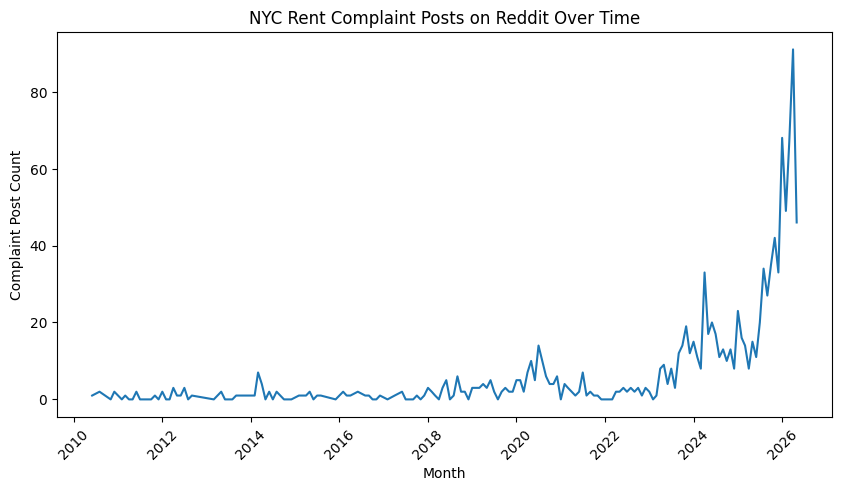

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(reddit_monthly["month"], reddit_monthly["complaint_count"])
plt.title("NYC Rent Complaint Posts on Reddit Over Time")
plt.xlabel("Month")
plt.ylabel("Complaint Post Count")
plt.xticks(rotation=45)
plt.show()

**Plot complaint share over time**

  The complaint share is very unstable in earlier years because there were few posts, but after 2022 it becomes more meaningful and generally shows that a sizable portion of rent-related posts are complaints.

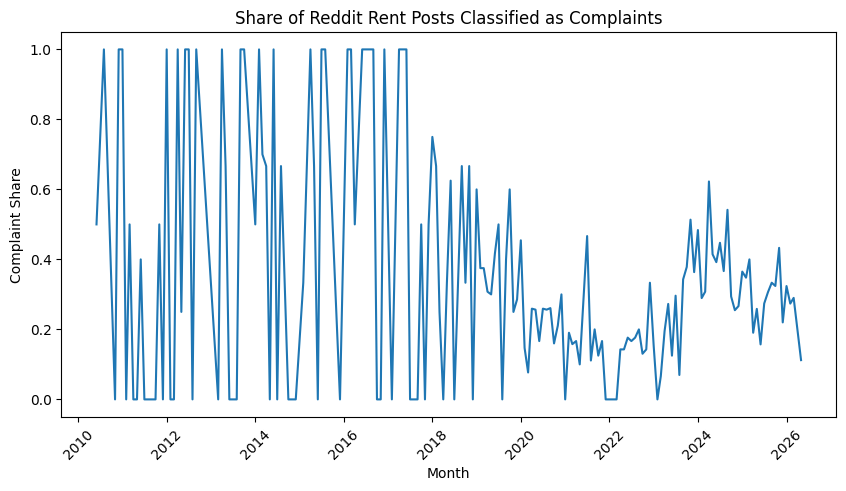

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(reddit_monthly["month"], reddit_monthly["complaint_share"])
plt.title("Share of Reddit Rent Posts Classified as Complaints")
plt.xlabel("Month")
plt.ylabel("Complaint Share")
plt.xticks(rotation=45)
plt.show()

**Plot average sentiment over time**

A lower score means posts are more negative on average.     Average sentiment stays mostly near or slightly above zero, with occasional negative spikes, suggesting that TextBlob sentiment does not capture rent frustration as clearly as the keyword-based complaint count

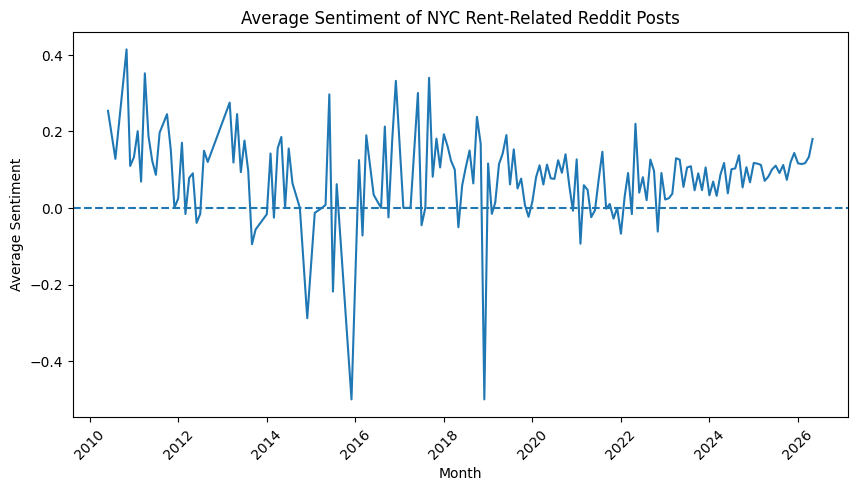

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(reddit_monthly["month"], reddit_monthly["avg_sentiment"])
plt.axhline(0, linestyle="--")
plt.title("Average Sentiment of NYC Rent-Related Reddit Posts")
plt.xlabel("Month")
plt.ylabel("Average Sentiment")
plt.xticks(rotation=45)
plt.show()

***Note:** We tried to merge the ZORI data frame with the scrapped reddit one, but found there's no data point on a same datetime in common. Merge data frame becomes empty.

### 4. Hypothesis

* Manhattan has the highest rent level.

* LIC has higher rent than many other Queens ZIP codes.

* Recent rent values are strong predictors of next month’s rent.

* 12-month lag captures yearly seasonality.

* Models with lag features should outperform a simple baseline.

## IV. Regression Modeling

### 1. Train-test split

**Define features and target**

In [ ]:
# Features used to predict next month's rent
features = [
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "year",
    "month",
    "quarter",
    "borough",
    "is_lic"
]

# Target variable: next month's rent
target = "target_next_month_rent"

X = model_df_final[features].copy()
y = model_df_final[target].copy()

**Time-based train-test split**

Because this is time-series data, random split is not suitable.

In [ ]:
# Check date range first
print(model_df_final["date"].min())
print(model_df_final["date"].max())

2016-01-31 00:00:00
2026-02-28 00:00:00


This means the model trains on 7,860 ZIP-code-month observations and tests on 2,989 future observations.

In [ ]:
# choose split date
split_date = "2024-01-01"

train_mask = model_df_final["date"] < split_date
test_mask = model_df_final["date"] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 7860
Testing rows: 2989


**Identify numeric and categorical columns**

  * Numerical features: scaled for models like KNN and Ridge.

  * Categorical features: one-hot encoded because models need numbers.

In [ ]:
numeric_features = [
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "year",
    "month",
    "quarter",
    "is_lic"
]

categorical_features = [
    "borough"
]

**Build Pipeline**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [ ]:
# scale numeric variables
# one-hot encode borough
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

### 2. Baseline Model

The dummy model predicts the average training rent for every test observation. It gives a baseline that real models should beat.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

A model must have an MAE lower than about $786 to be better than simply predicting the average rent for every observation. Because RMSE is much larger than MAE, it suggests some test observations have very large errors, probably expensive ZIP codes or high-rent months.

The dummy model performs especially **poorly** on ZIP codes with **rents far from the citywide average**, such as high-rent Manhattan or lower-rent outer-borough areas.

In [ ]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

dummy_mae = mean_absolute_error(y_test, y_pred_dummy)
dummy_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
dummy_r2 = r2_score(y_test, y_pred_dummy)

print("Dummy MAE:", dummy_mae)
print("Dummy RMSE:", dummy_rmse)
print("Dummy R²:", dummy_r2)

Dummy MAE: 785.5771858451099
Dummy RMSE: 1139.471459539281
Dummy R²: -0.26020065395276304


### 3. Linear Regression

Linear regression gives an interpretable baseline model. It assumes a linear relationship between lagged rent features, time variables, borough, and next month’s rent.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 33.90439135695537
Linear Regression RMSE: 47.6685681614002
Linear Regression R²: 0.9977945510420214


### 4. Ridge Regression

Ridge is good when lag variables are highly correlated. Ridge regression adds regularization, which reduces overfitting and helps when predictors such as current rent and lagged rent are strongly correlated.

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression MAE:", ridge_mae)
print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression MAE: 34.49534195866838
Ridge Regression RMSE: 47.747868310443636
Ridge Regression R²: 0.997787207087252


### 5. KNN Regression

KNN predicts rent by looking at similar ZIP-code-month observations. Because KNN is distance-based, scaling is necessary.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
knn_r2 = r2_score(y_test, y_pred_knn)

print("KNN Regression MAE:", knn_mae)
print("KNN Regression RMSE:", knn_rmse)
print("KNN Regression R²:", knn_r2)

KNN Regression MAE: 104.74339153706771
KNN Regression RMSE: 151.39772742160574
KNN Regression R²: 0.9777529972076568


### 6. Random Forest Regression

Random Forest can capture nonlinear relationships, but it is less interpretable than linear regression. It may perform better if rent trends differ across boroughs or ZIP codes in complex ways.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 43.24787668071862
Random Forest RMSE: 90.27570191985866
Random Forest R²: 0.9920900353114599


### 7. Model Comparison

The strong performance of **Linear Regression** is closely related to the **time-series structure** of the Zillow ZORI dataset. Since the target variable is next month’s rent and the model includes **current and lagged rent values**, the prediction problem contains strong autocorrelation. In other words, rent in one month is highly correlated with rent in nearby months. Because rent indices usually change gradually, next month’s rent can be approximated well as a linear function of recent rent levels and rent growth. Therefore, the linear model performs better than more complex models such as Random Forest and KNN. However, this should not be interpreted as a causal relationship; the model is identifying **predictive temporal patterns**, not proving that one variable causes another.

**MEA, RMEA, and R² Comparison**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Linear Regression",
        "Ridge Regression",
        "KNN Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        dummy_mae,
        linear_mae,
        ridge_mae,
        knn_mae,
        rf_mae
    ],
    "RMSE": [
        dummy_rmse,
        linear_rmse,
        ridge_rmse,
        knn_rmse,
        rf_rmse
    ],
    "R2": [
        dummy_r2,
        linear_r2,
        ridge_r2,
        knn_r2,
        rf_r2
    ]
})

results = results.sort_values("MAE")
results

,Model,MAE,RMSE,R2
1,Linear Regression,33.904391,47.668568,0.997795
2,Ridge Regression,34.495342,47.747868,0.997787
4,Random Forest Regression,43.247877,90.275702,0.992090
3,KNN Regression,104.743392,151.397727,0.977753
0,Dummy Regressor,785.577186,1139.471460,-0.260201


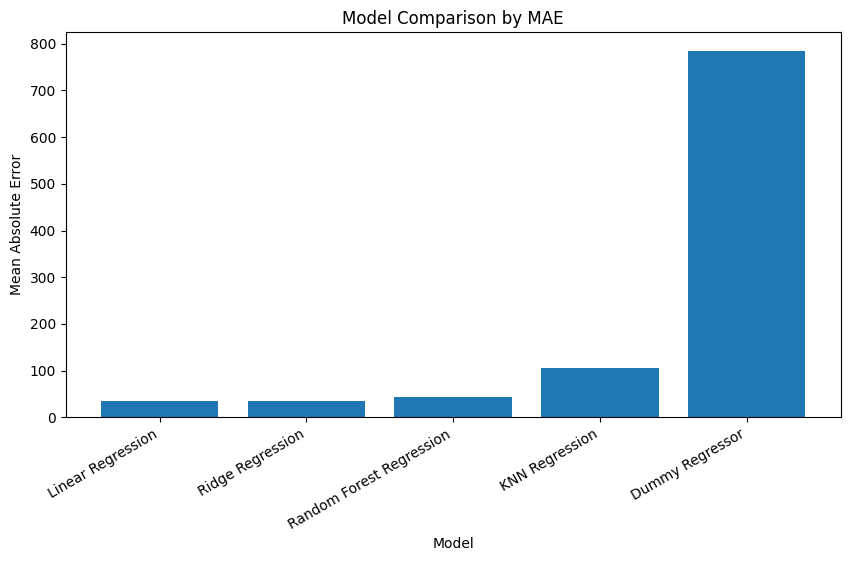

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=30, ha="right")
plt.show()

**Random Forest Prediction Accuracy**

The actual-versus-predicted plot shows that the Random Forest model performs well for most observations, with points closely following the diagonal reference line. However, **the model underpredicts very high-rent ZIP-code-month observations**, as shown by the **flattened prediction pattern** at the top-right of the graph. This helps explain why Random Forest has a higher RMSE than Linear Regression, despite still achieving a strong overall R².

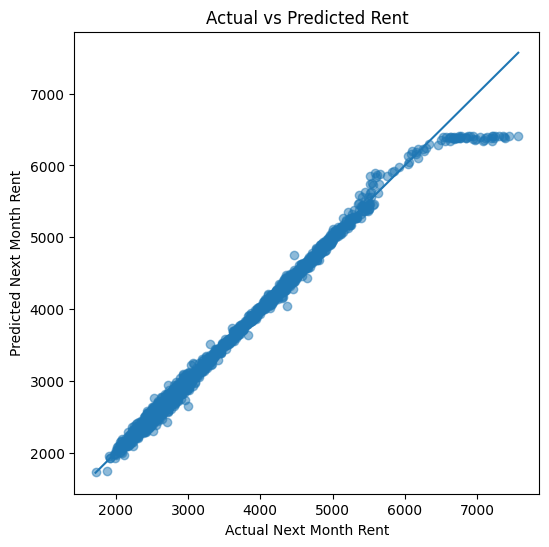

In [ ]:
best_pred = y_pred_rf

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted Rent")
plt.xlabel("Actual Next Month Rent")
plt.ylabel("Predicted Next Month Rent")
plt.show()

## V. Classification Model

### 1. Create classification target

    1 = ZIP-code-month is predicted to be high-rent next month
    0 = ZIP-code-month is predicted to be lower-rent next month

In [ ]:
# Create cutoff using the training period only to avoid data leakage
train_cutoff = model_df_final.loc[
    model_df_final["date"] < "2024-01-01",
    "target_next_month_rent"
].median()

print("High-rent cutoff:", train_cutoff)

# Create binary classification target
model_df_final["high_rent_next_month"] = (
    model_df_final["target_next_month_rent"] >= train_cutoff
).astype(int)

model_df_final["high_rent_next_month"].value_counts()

High-rent cutoff: 2651.898315946749


,count
high_rent_next_month,
1,6070
0,4779


### 2. Define X and y for classification

In [ ]:
features = [
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "year",
    "month",
    "quarter",
    "borough",
    "is_lic"
]

target_class = "high_rent_next_month"

X_class = model_df_final[features].copy()
y_class = model_df_final[target_class].copy()

### 3. Time-based train-test split

In [ ]:
split_date = "2024-01-01"

train_mask = model_df_final["date"] < split_date
test_mask = model_df_final["date"] >= split_date

X_train_class = X_class[train_mask]
X_test_class = X_class[test_mask]

y_train_class = y_class[train_mask]
y_test_class = y_class[test_mask]

print("Training rows:", X_train_class.shape[0])
print("Testing rows:", X_test_class.shape[0])

print("Train class balance:")
print(y_train_class.value_counts(normalize=True))

print("Test class balance:")
print(y_test_class.value_counts(normalize=True))

Training rows: 7860
Testing rows: 2989
Train class balance:
high_rent_next_month
1    0.5
0    0.5
Name: proportion, dtype: float64
Test class balance:
high_rent_next_month
1    0.715959
0    0.284041
Name: proportion, dtype: float64


### 4. Build preprocessing pipeline

In [ ]:
numeric_features = [
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "year",
    "month",
    "quarter",
    "is_lic"
]

categorical_features = ["borough"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

 ### 5. Logistic Regression classification

 Logistic Regression estimates whether next month’s rent will be above the high-rent cutoff. It is useful because it gives an interpretable classification model.

 Logistic Regression performs best in the classification task, with an **accuracy of 96.8%** and an F1 score of 0.977. The confusion matrix shows that **the model correctly identifies most high-rent ZIP-code-month observations**, with only 61 false negatives out of 2,140 actual high-rent cases.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

logistic_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_clf.fit(X_train_class, y_train_class)

y_pred_logistic = logistic_clf.predict(X_test_class)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test_class, y_pred_logistic))
print("Precision:", precision_score(y_test_class, y_pred_logistic))
print("Recall:", recall_score(y_test_class, y_pred_logistic))
print("F1:", f1_score(y_test_class, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_logistic))

Logistic Regression Results
Accuracy: 0.9678822348611575
Precision: 0.9834437086092715
Recall: 0.9714953271028037
F1: 0.9774330042313117

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       849
           1       0.98      0.97      0.98      2140

    accuracy                           0.97      2989
   macro avg       0.96      0.97      0.96      2989
weighted avg       0.97      0.97      0.97      2989



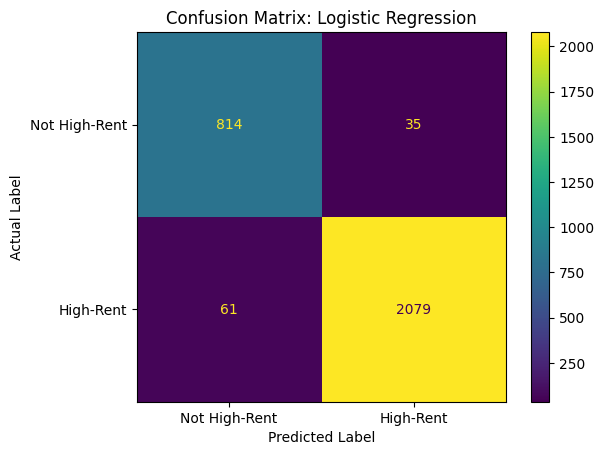

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create confusion matrix for Logistic Regression
cm_logistic = confusion_matrix(y_test_class, y_pred_logistic)

# Plot confusion matrix
disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not High-Rent", "High-Rent"]

)

disp_logistic.plot(values_format="d")
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### 6. KNN Classification

KNN Classification predicts whether a ZIP-code-month is high-rent by looking at similar observations in the training data.

KNN Classification performs reasonably well, with an **accuracy of 89.5%**, but it produces **more false negatives and has a lower recall**.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_clf.fit(X_train_class, y_train_class)

y_pred_knn_class = knn_clf.predict(X_test_class)

print("KNN Classification Results")
print("Accuracy:", accuracy_score(y_test_class, y_pred_knn_class))
print("Precision:", precision_score(y_test_class, y_pred_knn_class))
print("Recall:", recall_score(y_test_class, y_pred_knn_class))
print("F1:", f1_score(y_test_class, y_pred_knn_class))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_knn_class))

KNN Classification Results
Accuracy: 0.8946135831381733
Precision: 0.9672299027137736
Recall: 0.8827102803738318
F1: 0.9230393354507697

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       849
           1       0.97      0.88      0.92      2140

    accuracy                           0.89      2989
   macro avg       0.86      0.90      0.88      2989
weighted avg       0.91      0.89      0.90      2989



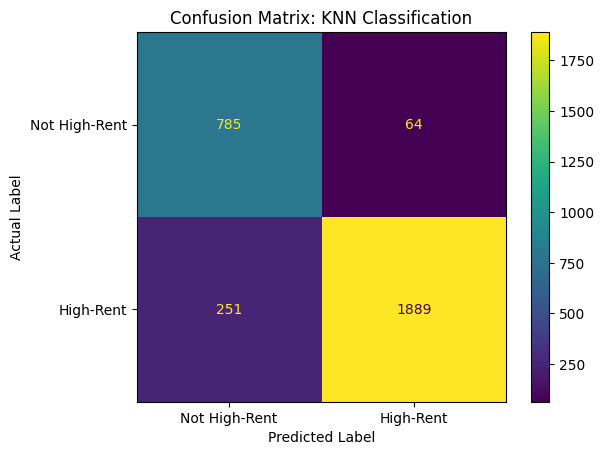

In [ ]:
# Create confusion matrix for KNN Classification
cm_knn = confusion_matrix(y_test_class, y_pred_knn_class)

# Plot confusion matrix
disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Not High-Rent", "High-Rent"]
)

disp_knn.plot(values_format="d")

plt.title("Confusion Matrix: KNN Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

###  7. Classification comparison table

The result suggests that **the high-rent classification boundary is relatively linear** and can be captured effectively by **Logistic Regression** using current rent, lagged rent, rent growth, time, and borough features.

In [ ]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN Classification"
    ],
    "Accuracy": [
        accuracy_score(y_test_class, y_pred_logistic),
        accuracy_score(y_test_class, y_pred_knn_class)
    ],
    "Precision": [
        precision_score(y_test_class, y_pred_logistic),
        precision_score(y_test_class, y_pred_knn_class)
    ],
    "Recall": [
        recall_score(y_test_class, y_pred_logistic),
        recall_score(y_test_class, y_pred_knn_class)
    ],
    "F1": [
        f1_score(y_test_class, y_pred_logistic),
        f1_score(y_test_class, y_pred_knn_class)
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.967882,0.983444,0.971495,0.977433
1,KNN Classification,0.894614,0.967230,0.882710,0.923039


## VI. Prediction Model

 In the forecasting extension, we compare a naive baseline, ARIMA, and Exponential Smoothing using NYC average monthly ZORI rent. The **naive model** performs worst, with an MAE of about 123, because it does not adjust well to the recent high-rent period. **ARIMA** improves substantially, reducing MAE to about 37, showing that the **time-series structure** contains useful forecasting information. **Exponential Smoothing** performs best, with an MAE of about 23 and RMSE of about 29. This suggests that **NYC rent trends are smooth** and recent observations are especially informative for short-term forecasting.

In [ ]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 11.3 MB/s eta 0:00:00


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.6 MB/s eta 0:00:00


### 1. Create a monthly time series

In [ ]:
# Create NYC-wide monthly average rent series
nyc_monthly = (
    zori_long
    .groupby("date")["zori_rent"]
    .mean()
    .reset_index()
    .sort_values("date")
)

nyc_monthly.head()

,date,zori_rent
0,2015-01-31,2659.788580
1,2015-02-28,2674.953349
2,2015-03-31,2672.698850
3,2015-04-30,2673.067202
4,2015-05-31,2659.813680


### 2. Convert to sktime format

In [ ]:
# Convert date column to monthly period index
y = nyc_monthly.set_index("date")["zori_rent"]

# Convert datetime index to monthly period index
y.index = y.index.to_period("M")

# Check the series
y.head()

,zori_rent
date,
2015-01,2659.788580
2015-02,2674.953349
2015-03,2672.698850
2015-04,2673.067202
2015-05,2659.813680


**Plot original series**

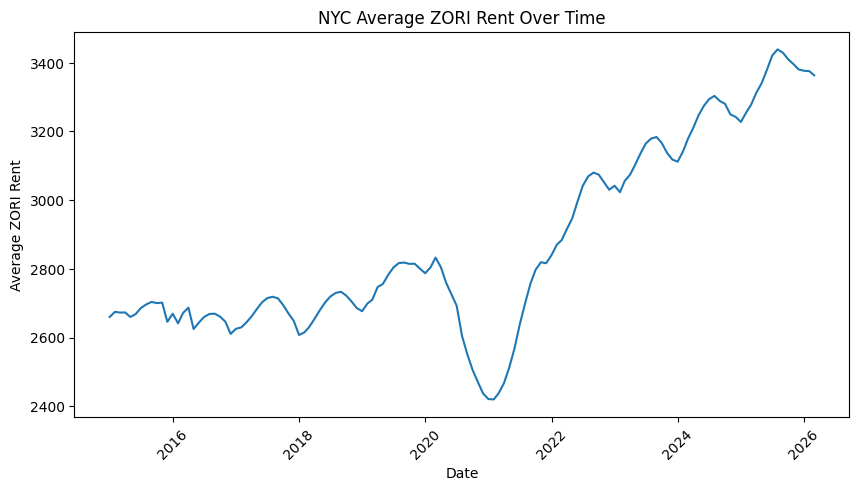

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y.index.to_timestamp(), y.values)
plt.title("NYC Average ZORI Rent Over Time")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.xticks(rotation=45)
plt.show()

### 4. Train-test split for forecasting

In [ ]:
from sktime.forecasting.model_selection import temporal_train_test_split

# Use last 12 months as test set
y_train, y_test = temporal_train_test_split(y, test_size=12)

print("Training period:", y_train.index.min(), "to", y_train.index.max())
print("Testing period:", y_test.index.min(), "to", y_test.index.max())

Training period: 2015-01 to 2025-03
Testing period: 2025-04 to 2026-03


### 5. Create forecasting horizon

In [ ]:
from sktime.forecasting.base import ForecastingHorizon

# Forecast the same dates as the test set
fh = ForecastingHorizon(y_test.index, is_relative=False)

fh

ForecastingHorizon(['2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09',
             '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03'],
            dtype='period[M]', name='date', is_relative=False)

#### Model 1: Natice Forcasting Baseline

The Naive Forecast is much **less accurate** because it mostly repeats past patterns and **does not adjust well to the recent rent level**. In the plots, the naive line stays too low compared with the actual test rent.

In [ ]:
from sktime.forecasting.naive import NaiveForecaster

# Seasonal naive model: predicts using the same month from last year
naive_forecaster = NaiveForecaster(strategy="last", sp=12)

naive_forecaster.fit(y_train)

y_pred_naive = naive_forecaster.predict(fh)

y_pred_naive.head()

,zori_rent
date,
2025-04,3210.977307
2025-05,3246.808609
2025-06,3274.488238
2025-07,3293.777700
2025-08,3303.153046


**Evaluate**

In [ ]:
from sktime.performance_metrics.forecasting import mean_absolute_error, mean_squared_error
import numpy as np

naive_mae = mean_absolute_error(y_test, y_pred_naive)
naive_rmse = np.sqrt(mean_squared_error(y_test, y_pred_naive))

print("Naive Forecast MAE:", naive_mae)
print("Naive Forecast RMSE:", naive_rmse)

Naive Forecast MAE: 122.61510947030725
Naive Forecast RMSE: 124.307401318946


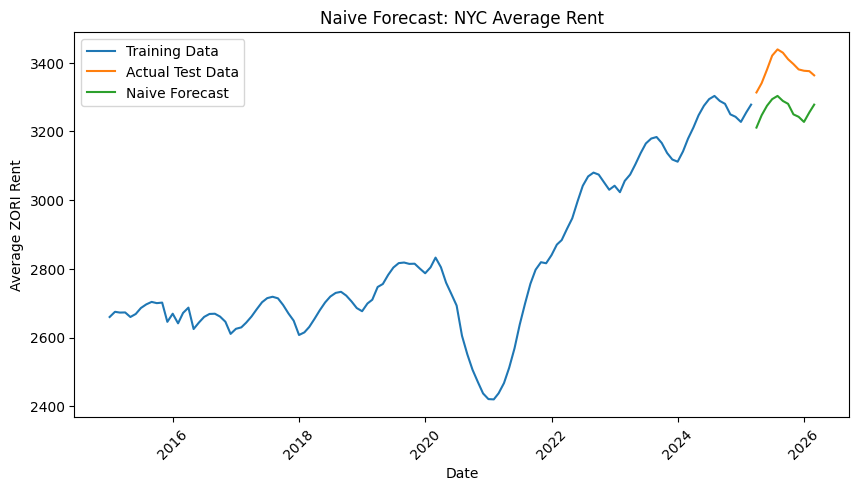

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(y_train.index.to_timestamp(), y_train.values, label="Training Data")
plt.plot(y_test.index.to_timestamp(), y_test.values, label="Actual Test Data")
plt.plot(y_pred_naive.index.to_timestamp(), y_pred_naive.values, label="Naive Forecast")

plt.title("Naive Forecast: NYC Average Rent")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### Model 2: ARIMA Forcasting

ARIMA tracks the test period **much better**. It captures the general trend and **stays close to actual rent**, but it slightly **underpredicts some of the higher values**.

In [ ]:
from sktime.forecasting.arima import AutoARIMA

# AutoARIMA automatically searches for a good ARIMA specification
arima_forecaster = AutoARIMA(
    seasonal=True,
    sp=12,
    suppress_warnings=True
)

arima_forecaster.fit(y_train)

y_pred_arima = arima_forecaster.predict(fh)

y_pred_arima.head()

,zori_rent
date,
2025-04,3301.623988
2025-05,3327.543649
2025-06,3348.976733
2025-07,3363.929812
2025-08,3371.551979


In [ ]:
arima_mae = mean_absolute_error(y_test, y_pred_arima)
arima_rmse = np.sqrt(mean_squared_error(y_test, y_pred_arima))

print("ARIMA Forecast MAE:", arima_mae)
print("ARIMA Forecast RMSE:", arima_rmse)

ARIMA Forecast MAE: 36.59182564584413
ARIMA Forecast RMSE: 40.66471273089448


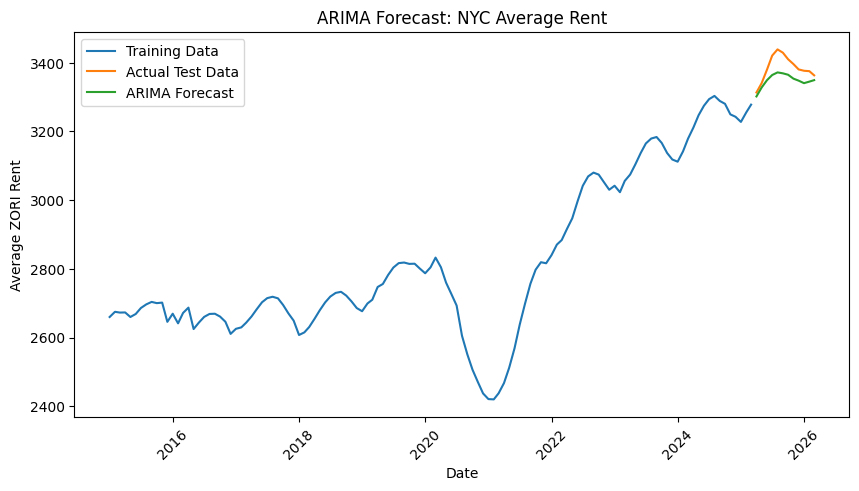

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(y_train.index.to_timestamp(), y_train.values, label="Training Data")
plt.plot(y_test.index.to_timestamp(), y_test.values, label="Actual Test Data")
plt.plot(y_pred_arima.index.to_timestamp(), y_pred_arima.values, label="ARIMA Forecast")

plt.title("ARIMA Forecast: NYC Average Rent")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### 6. Compare Naive vs ARIMA

In [ ]:
forecast_results = pd.DataFrame({
    "Model": ["Naive Forecast", "ARIMA"],
    "MAE": [naive_mae, arima_mae],
    "RMSE": [naive_rmse, arima_rmse]
})

forecast_results

,Model,MAE,RMSE
0,Naive Forecast,122.615109,124.307401
1,ARIMA,36.591826,40.664713


In this plot, the historical rent series shows a clear **COVID-era drop** around 2020–2021, **followed by a strong recovery and upward trend after 2021**. During the test period, ARIMA is much closer to actual rent than the naive forecast, while the naive forecast **consistently underpredicts**.

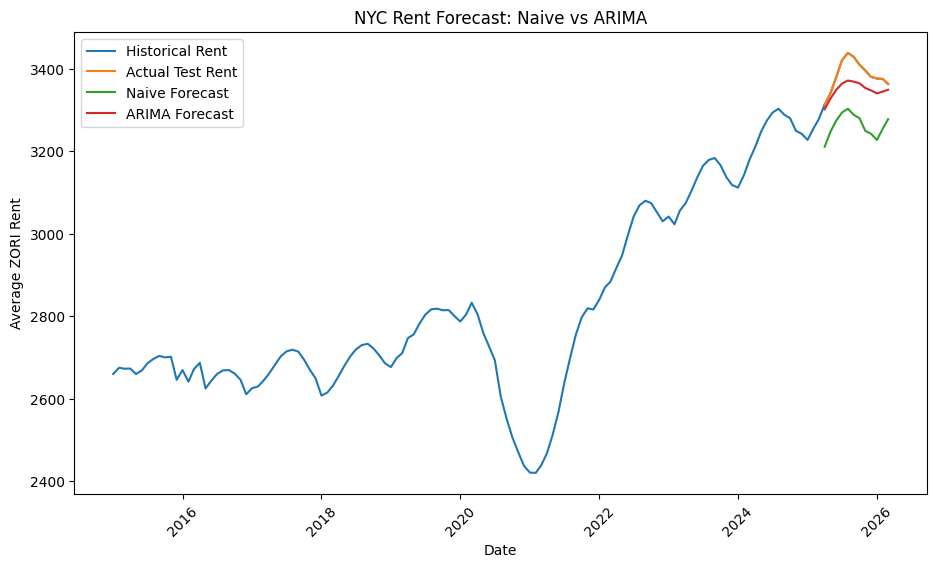

In [ ]:
plt.figure(figsize=(11, 6))

# Plot full historical series lightly
plt.plot(y.index.to_timestamp(), y.values, label="Historical Rent")

# Highlight test period
plt.plot(y_test.index.to_timestamp(), y_test.values, label="Actual Test Rent")

# Forecast lines
plt.plot(y_pred_naive.index.to_timestamp(), y_pred_naive.values, label="Naive Forecast")
plt.plot(y_pred_arima.index.to_timestamp(), y_pred_arima.values, label="ARIMA Forecast")

plt.title("NYC Rent Forecast: Naive vs ARIMA")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### 8. Forecast future 12 months

In the 12-month forecast plot, **ARIMA** predicts that NYC average rent will **remain high** **but relatively stable**, staying around the upper **$3,300 range** rather than continuing to rise sharply. This suggests the **model expects slower rent growth** after the recent post-pandemic increase.

In [ ]:
# Fit ARIMA on the full time series
final_arima = AutoARIMA(
    seasonal=True,
    sp=12,
    suppress_warnings=True
)

final_arima.fit(y)

# Forecast next 12 months
future_fh = list(range(1, 13))

future_pred = final_arima.predict(future_fh)

future_pred

,zori_rent
2026-04,3366.066462
2026-05,3374.329515
2026-06,3382.254711
2026-07,3386.783673
2026-08,3386.851287
2026-09,3383.059353
2026-10,3377.124147
2026-11,3371.150824
2026-12,3366.930087
2027-01,3365.447864


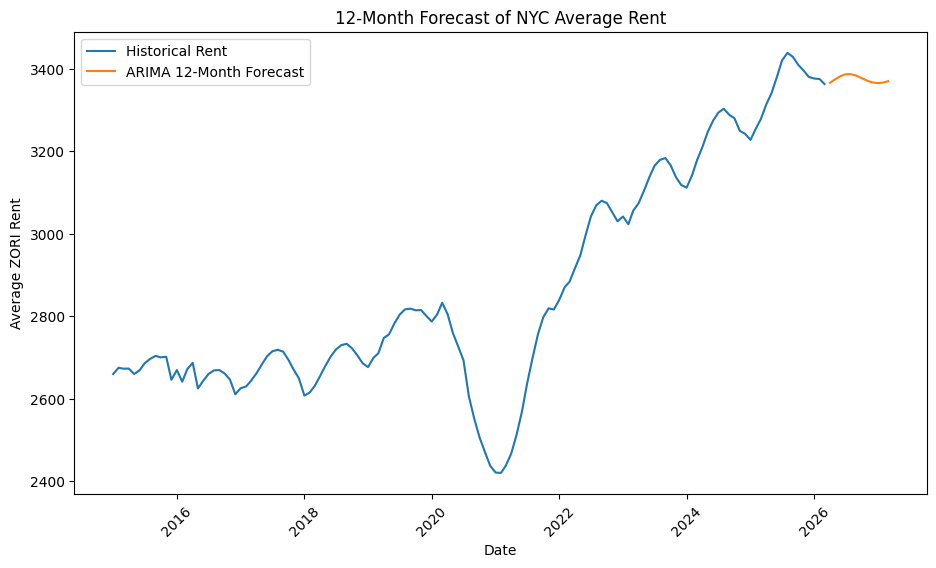

In [ ]:
plt.figure(figsize=(11, 6))

plt.plot(y.index.to_timestamp(), y.values, label="Historical Rent")
plt.plot(future_pred.index.to_timestamp(), future_pred.values, label="ARIMA 12-Month Forecast")

plt.title("12-Month Forecast of NYC Average Rent")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### 9. Smoothing

**Exponential Smoothing** performs best because NYC average rent changes smoothly over time, and this method gives more weight to recent observations. Since recent rent levels are highly informative, exponential smoothing **adapts better to the test period**.

In [ ]:
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

exp_forecaster = ExponentialSmoothing(
    trend="add",
    seasonal="add",
    sp=12
)

exp_forecaster.fit(y_train)

y_pred_exp = exp_forecaster.predict(fh)

exp_mae = mean_absolute_error(y_test, y_pred_exp)
exp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_exp))

print("Exponential Smoothing MAE:", exp_mae)
print("Exponential Smoothing RMSE:", exp_rmse)

Exponential Smoothing MAE: 22.944936684492216
Exponential Smoothing RMSE: 29.334595062565924


Exponential Smoothing performs best, ARIMA performs second best, and the Naive Forecast is the weakest baseline.

In [ ]:
forecast_results = pd.DataFrame({
    "Model": ["Naive Forecast", "ARIMA", "Exponential Smoothing"],
    "MAE": [naive_mae, arima_mae, exp_mae],
    "RMSE": [naive_rmse, arima_rmse, exp_rmse]
})

forecast_results

,Model,MAE,RMSE
0,Naive Forecast,122.615109,124.307401
1,ARIMA,36.591826,40.664713
2,Exponential Smoothing,22.944937,29.334595


In the test-period comparison plot, **Exponential Smoothing** follows the actual rent line **most closely**, especially around late 2025 and early 2026, while Naive Forecast stays too low and **ARIMA is moderately accurate** but smoother.

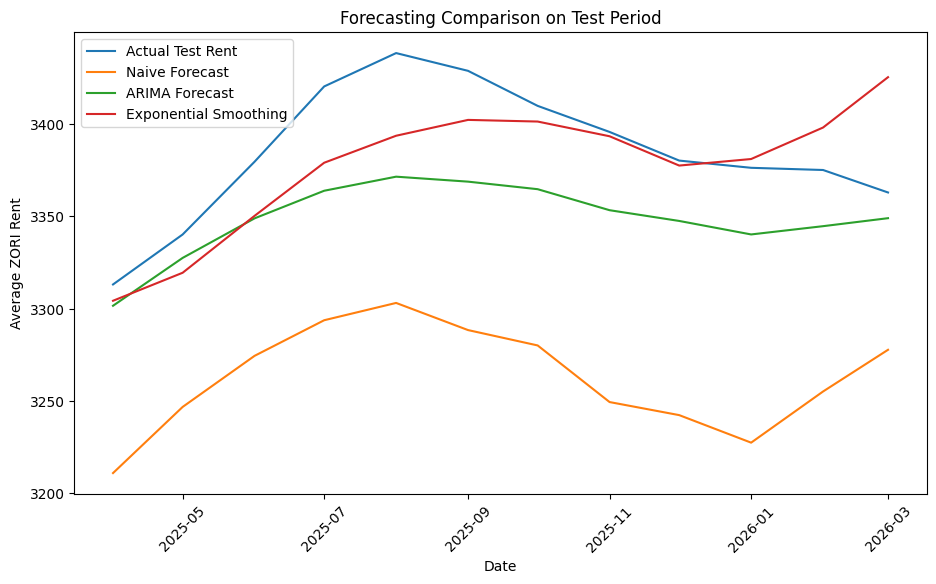

In [ ]:
plt.figure(figsize=(11, 6))

plt.plot(y_test.index.to_timestamp(), y_test.values, label="Actual Test Rent")
plt.plot(y_pred_naive.index.to_timestamp(), y_pred_naive.values, label="Naive Forecast")
plt.plot(y_pred_arima.index.to_timestamp(), y_pred_arima.values, label="ARIMA Forecast")
plt.plot(y_pred_exp.index.to_timestamp(), y_pred_exp.values, label="Exponential Smoothing")

plt.title("Forecasting Comparison on Test Period")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## VII. Conclusion

* Main finding:

  The **EDA** shows that NYC rent has **strong location differences** and clear **time-series patterns**. Consistent with this, **historical rent values** are the strongest predictors of future NYC rent. Because rent changes gradually over time, current and lagged rent variables are highly useful for prediction.


*   EDA finding:
  
    The EDA shows clear **spatial and temporal patterns** in NYC rent. **Manhattan** and **LIC** have much higher rent levels, while Queens, the Bronx, and Staten Island are more concentrated in lower rent ranges. Rent growth also shows a sharp COVID-era disruption followed by a strong rebound after 2021.
    

* Best regression model:

  **Linear Regression** performs best, with an MAE of about $34 and an R² of about 0.998. This suggests that next-month rent can be predicted very accurately using recent rent trends.

* Classification result:

  **Logistic Regression** performs better than KNN Classification for predicting whether a ZIP-code-month will be high-rent, with an accuracy of about 96.8%.

* Forecasting result:

  **Exponential Smoothing** performs best among the time-series models, outperforming both ARIMA and the naive baseline. This shows that recent rent observations are especially important for short-term forecasting.

* Limitations:

  **ZORI is an aggregated rent index, not individual apartment listing data**, so the model cannot capture apartment-level features such as bedrooms, amenities, building quality, or exact address.

* Next steps:

  Future work could **add subway access, income data, new housing supply, or individual rental listing data** to better explain neighborhood-level rent differences.